<a href="https://colab.research.google.com/github/tinemyumi/saude-mental-datasus/blob/main/notebooks/7.perfil_sociodemografico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perfil Sociodemográfico**

## **Objetivo**
Descrever o perfil dos pacientes internados em saúde mental (SP, 2015–2025)
segundo idade, sexo e etnia/cor, comparando os três períodos pandêmicos.

**Autor:** Larissa Tinem


## **1. Setup**

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# Paleta e estilo
COLOR1 = '#1B4F72'
COLOR2 = '#48C9B0'
COLOR3 = '#5499C7'
PALETTE_PERIODO = {
    'pre-pandemia' : COLOR1,
    'pandemia'     : COLOR2,
    'pos-pandemia' : COLOR3,
}
ORDEM_PERIODOS = ['pre-pandemia', 'pandemia', 'pos-pandemia']

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

SAVEPATH = '/content/drive/MyDrive/Dataframes/'

## **2. Carregamento e Preparo**

In [14]:
df = pd.read_parquet('/content/drive/MyDrive/Dados/dados_tratados/df_sihsus.parquet')
df_pop = pd.read_csv('/content/drive/MyDrive/Dados/dados_tratados/df_populacao_sp')

df['periodo'] = pd.Categorical(df['periodo_pandemia'], categories=ORDEM_PERIODOS, ordered=True)


In [15]:
# Decodificações

df['SEXO_DESC'] = df['SEXO'].map({'1': 'Masculino', '3': 'Feminino'})

df['ETNIA_DESC'] = df['RACA_COR'].map({
    '01': 'Branca',
    '02': 'Parda',
    '03': 'Preta',
    '04': 'Amarela',
    '05': 'Indígena',
    '99': 'Ignorado'
})

df['FAIXA_ETARIA'] = pd.cut(
    df['IDADE'],
    bins=[0, 17, 29, 44, 59, 120],
    labels=['0–17', '18–29', '30–44', '45–59', '60+'],
    right=True
)

print('Decodificações aplicadas.')
print(df[['SEXO_DESC', 'ETNIA_DESC', 'FAIXA_ETARIA']].nunique())

Decodificações aplicadas.
SEXO_DESC       2
ETNIA_DESC      6
FAIXA_ETARIA    5
dtype: int64


## **3. Idade**

### **3.1 Distribuição Geral**


In [16]:
# Definir ordem correta
df['periodo_pandemia'] = pd.Categorical(
    df['periodo_pandemia'],
    categories=['pre-pandemia', 'pandemia', 'pos-pandemia'],
    ordered=True
)

# Estatísticas descritivas por idade
idade_desc = (
    df.groupby('periodo_pandemia', observed=True)['IDADE']
    .agg(
        media='mean',
        mediana='median',
        dp='std',
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
    .round(1)
)

print(idade_desc)

                  media  mediana    dp   p25   p75
periodo_pandemia                                  
pre-pandemia       44.5     44.0  16.3  32.0  56.0
pandemia           42.5     42.0  15.9  30.0  53.0
pos-pandemia       40.7     40.0  15.0  29.0  50.0


### **3.2 Faixas Etárias por Período**

In [17]:
# Agrupa por período e faixa etária contando internações únicas
df_idade = (
    df.groupby(['periodo_pandemia', 'FAIXA_ETARIA'])['N_AIH']
    .nunique()
    .reset_index(name='internacoes')
)

# Calcula o percentual de cada faixa etária dentro de cada período
df_idade['percentual'] = (
    df_idade.groupby('periodo_pandemia')['internacoes']
    .transform(lambda x: x / x.sum())
) * 100

# Reorganiza os dados em formato de tabela
df_idade = df_idade.pivot(
    index='periodo_pandemia',
    columns='FAIXA_ETARIA',
    values='percentual'
).fillna(0)

print(df_idade)

/tmp/ipykernel_17030/2820472327.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['periodo_pandemia', 'FAIXA_ETARIA'])['N_AIH']


FAIXA_ETARIA          0–17      18–29      30–44      45–59        60+
periodo_pandemia                                                      
pre-pandemia      4.286039  23.222390  35.705458  26.318357  10.467757
pandemia          4.300057  24.769302  35.306110  25.056152  10.568380
pos-pandemia      4.541084  25.038397  36.794222  23.553854  10.072443


/tmp/ipykernel_17030/2820472327.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_idade.groupby('periodo_pandemia')['internacoes']


/tmp/ipykernel_17030/3164758881.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


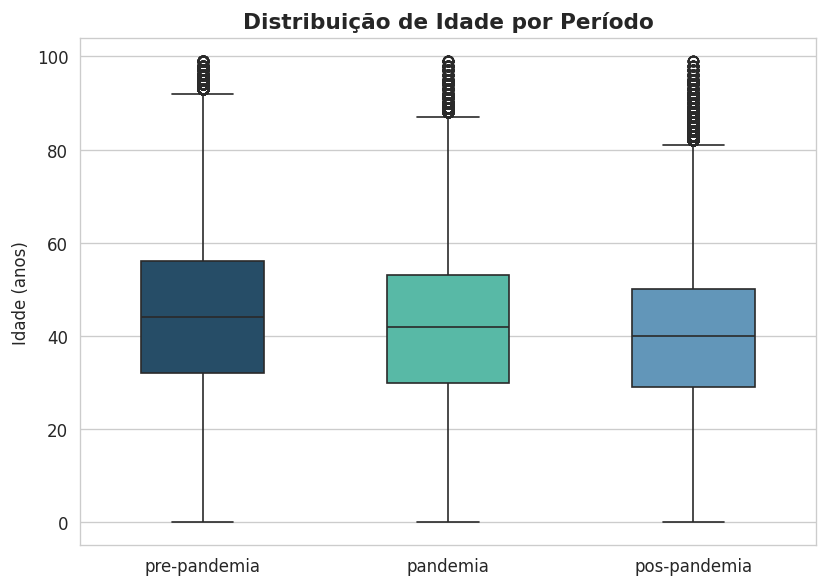

In [18]:
# Boxplot de idade por período
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df, x='periodo_pandemia', y='IDADE',
    palette=PALETTE_PERIODO,
    order=ORDEM_PERIODOS,
    width=0.5, ax=ax
)

ax.set_title('Distribuição de Idade por Período', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Idade (anos)')
plt.tight_layout()
plt.show()

### **3.3 Teste Estatístico (Idade)**

In [19]:
# Kruskal-Wallis: a distribuição de idade difere entre períodos?
grupos_idade = [df[df['periodo_pandemia'] == p]['IDADE'].values for p in ORDEM_PERIODOS]
stat, p_val = stats.kruskal(*grupos_idade)

print('=== Kruskal-Wallis — Idade por Período ===================')
print(f'H = {stat:.4f} | p-valor = {p_val:.4e}')
print(f'Conclusão: {"Distribuição de idade difere significativamente" if p_val < 0.05 else "Sem diferença significativa"} entre períodos (α=0.05)')

=== Kruskal-Wallis — Idade por Período ===================
H = 11666.8324 | p-valor = 0.0000e+00
Conclusão: Distribuição de idade difere significativamente entre períodos (α=0.05)


## **4. Sexo**

In [20]:
# Total de internações por sexo
tabela_sexo = (
    df.groupby('SEXO_DESC')['N_AIH']
    .nunique()
    .sort_values(ascending=False)
)
print('======= TOTAL DE INTERNAÇÕES POR SEXO =======\n')
print(tabela_sexo)

# Proporção por sexo
prop_sexo = tabela_sexo / tabela_sexo.sum() * 100
print('\n======= PROPORÇÃO POR SEXO =======\n')
print(prop_sexo.round(1))

# Sexo por período
print('\n======= SEXO POR PERÍODO =======\n')
tabela_periodo_sexo = (
    df.groupby(['periodo_pandemia', 'SEXO_DESC'])['N_AIH']
    .nunique()
    .unstack(fill_value=0)
)
print(tabela_periodo_sexo)

# Proporção por período
print('\n======= PROPORÇÃO POR PERÍODO =======\n')
prop_periodo_sexo = (
    tabela_periodo_sexo
    .div(tabela_periodo_sexo.sum(axis=1), axis=0)
    * 100
)
print(prop_periodo_sexo.round(1))

# Variação entre períodos
print('\n======= VARIAÇÃO ENTRE PERÍODOS =======\n')
variacao = prop_periodo_sexo.diff()
print(variacao.round(1))


======= TOTAL DE INTERNAÇÕES POR SEXO =======

SEXO_DESC
Masculino    375270
Feminino     261559
Name: N_AIH, dtype: int64

======= PROPORÇÃO POR SEXO =======

SEXO_DESC
Masculino    58.9
Feminino     41.1
Name: N_AIH, dtype: float64

======= SEXO POR PERÍODO =======



/tmp/ipykernel_17030/3381327291.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['periodo_pandemia', 'SEXO_DESC'])['N_AIH']


SEXO_DESC         Feminino  Masculino
periodo_pandemia                     
pre-pandemia        122019     180368
pandemia             46104      64474
pos-pandemia         95225     134222

======= PROPORÇÃO POR PERÍODO =======

SEXO_DESC         Feminino  Masculino
periodo_pandemia                     
pre-pandemia          40.4       59.6
pandemia              41.7       58.3
pos-pandemia          41.5       58.5

======= VARIAÇÃO ENTRE PERÍODOS =======

SEXO_DESC         Feminino  Masculino
periodo_pandemia                     
pre-pandemia           NaN        NaN
pandemia               1.3       -1.3
pos-pandemia          -0.2        0.2


## **5. Etnia/Cor**

In [21]:
# Proporção de etnia - contexto geral
etnia = (
    df.groupby('ETNIA_DESC')['N_AIH']
    .nunique()
    .sort_values(ascending=False)
)

prop_etnia = etnia / etnia.sum() * 100
print('======= PROPORÇÃO DE ETNIA =======\n')
print(prop_etnia.round(1))

# Proporção de 'ignorado' na base
ignorado = prop_etnia.get('Ignorado', 0)
print('\n======= PROPORÇÃO DE IGNORADOS =======\n')
print(f"Ignorados: {ignorado:.1f}%")

# Proporção de etnia por período
etnia_periodo = (
    df.groupby(['periodo', 'ETNIA_DESC'])['N_AIH']
    .nunique()
    .unstack(fill_value=0)
)

prop_etnia_periodo = (
    etnia_periodo
    .div(etnia_periodo.sum(axis=1), axis=0)
    * 100
)
print('\n================ PROPORÇÃO DE ETNIA POR PERÍODO ================\n')
print(prop_etnia_periodo.round(1))

# Variação entre períodos
variacao_etnia = prop_etnia_periodo.diff()
print('\n================ VARIAÇÃO ENTRE PERÍODOS ======================\n')
print(variacao_etnia.round(1))

======= PROPORÇÃO DE ETNIA =======

ETNIA_DESC
Branca      50.5
Preta       30.0
Ignorado    10.6
Parda        8.2
Amarela      0.6
Indígena     0.0
Name: N_AIH, dtype: float64

======= PROPORÇÃO DE IGNORADOS =======

Ignorados: 10.6%


/tmp/ipykernel_17030/298930420.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['periodo', 'ETNIA_DESC'])['N_AIH']



================ PROPORÇÃO DE ETNIA POR PERÍODO ================

ETNIA_DESC    Amarela  Branca  Ignorado  Indígena  Parda  Preta
periodo                                                        
pre-pandemia      0.5    50.4      16.3       0.0    7.7   25.0
pandemia          0.6    47.9      14.4       0.0    8.3   28.8
pos-pandemia      0.8    52.1       1.2       0.0    8.8   37.1

================ VARIAÇÃO ENTRE PERÍODOS ======================

ETNIA_DESC    Amarela  Branca  Ignorado  Indígena  Parda  Preta
periodo                                                        
pre-pandemia      NaN     NaN       NaN       NaN    NaN    NaN
pandemia          0.1    -2.6      -1.9       0.0    0.5    3.8
pos-pandemia      0.2     4.2     -13.2       0.0    0.5    8.3


In [22]:
variacao_etnia = prop_etnia_periodo.diff()
print(variacao_etnia.round(1))

ETNIA_DESC    Amarela  Branca  Ignorado  Indígena  Parda  Preta
periodo                                                        
pre-pandemia      NaN     NaN       NaN       NaN    NaN    NaN
pandemia          0.1    -2.6      -1.9       0.0    0.5    3.8
pos-pandemia      0.2     4.2     -13.2       0.0    0.5    8.3
